# Лабораторная работа 4 - Линейные модели, SVM и деревья решений.


## 1. Загрузка данных и предобработка
Загружаем «Титаник», смотрим пропуски. Выбираем признаки.
Заполняем пропуски: для числовых — медианой, для категориальных — самой частой категорией.
Категориальные признаки кодируем через OneHotEncoder, числовые масштабируем (StandardScaler).
Вся предобработка оформлена в ColumnTransformer.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Загрузка
df = sns.load_dataset('titanic')
df = df.dropna(subset=['survived'])   # убираем строки без целевой переменной

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived']

# Типы признаков
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked', 'pclass']

# Трансформеры
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

##2. Разделение на обучающую и тестовую выборки
Откладываем 20 % данных для финальной оценки. Стратифицируем по целевому признаку, чтобы сохранить баланс классов.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##3. Создание и обучение моделей
Для каждой модели строим пайплайн: предобработка + классификатор.
Для дерева решений задаём max_depth=3, чтобы впоследствии получить читаемую визуализацию.
SVM используем с RBF-ядром и стандартными параметрами.

In [ ]:
# Логистическая регрессия
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipe_lr.fit(X_train, y_train)

# Метод опорных векторов
pipe_svm = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', SVC(kernel='rbf', random_state=42))])
pipe_svm.fit(X_train, y_train)

# Дерево решений (ограниченная глубина для наглядности)
pipe_tree = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))])
pipe_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=3, random_state=42))])

##4. Оценка качества и сравнение
На тестовой выборке считаем Accuracy и F1-score (макро или взвешенный — возьмём average='binary', так как задача бинарной классификации). Выводим сводку.

In [ ]:
models = {'Logistic Regression': pipe_lr,
          'SVM': pipe_svm,
          'Decision Tree (max_depth=3)': pipe_tree}

print("    Сравнение моделей    ")
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')
    print(f"{name:30} | Accuracy: {acc:.4f} | F1-score: {f1:.4f}")

# При желании можно посмотреть полный отчёт по лучшей или по каждой модели

    Сравнение моделей    
Logistic Regression            | Accuracy: 0.8045 | F1-score: 0.7244
SVM                            | Accuracy: 0.8156 | F1-score: 0.7360
Decision Tree (max_depth=3)    | Accuracy: 0.7933 | F1-score: 0.6726


##5. График важности признаков для дерева решений
Извлекаем обученное дерево из пайплайна, получаем feature_importances_.
Формируем имена признаков такими, какими их видит модель после OneHot-кодирования.

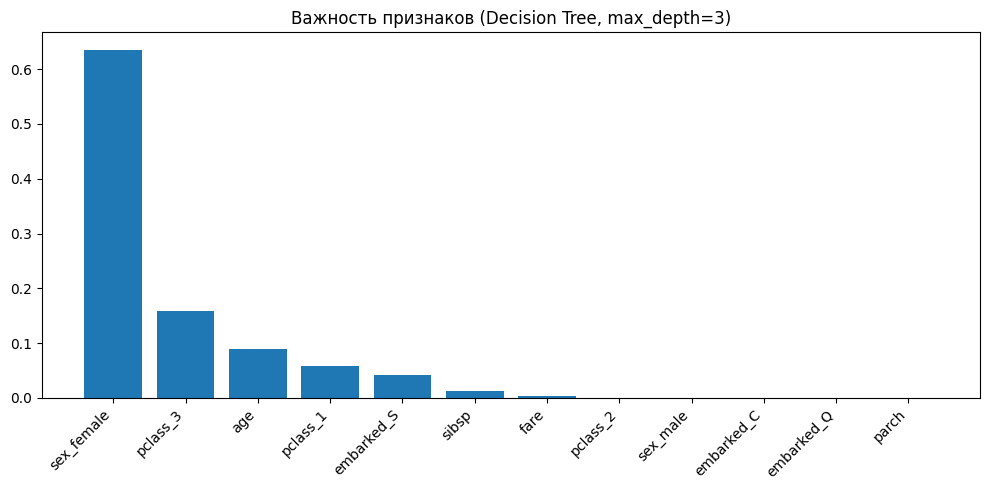

In [ ]:
# Достаём обученное дерево и препроцессор
tree_model = pipe_tree.named_steps['classifier']
prep = pipe_tree.named_steps['preprocessor']

# Получаем итоговые названия признаков после кодирования
# Для числовых – исходные имена, для категориальных – генерируем через OneHotEncoder
cat_encoder = prep.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

# Строим столбчатую диаграмму
importances = tree_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Важность признаков (Decision Tree, max_depth=3)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), all_feature_names[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

##6. Визуализация дерева решений
Используем plot_tree из sklearn.tree. Чтобы рисунок оставался читаемым, дерево уже ограничено глубиной 3.
Можно также вывести правила текстом (через export_text), но визуализация нагляднее.

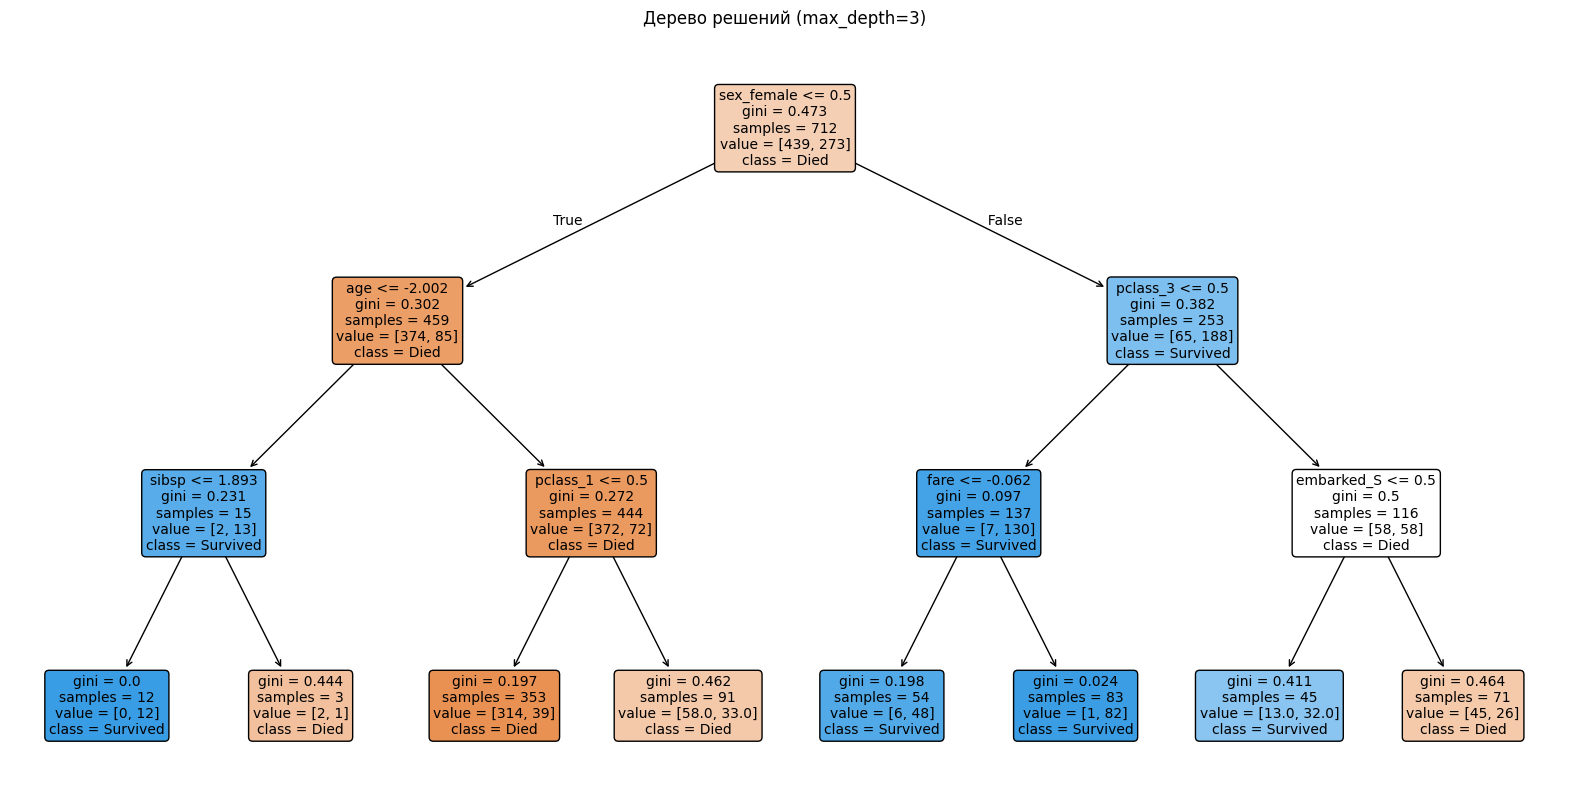

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=all_feature_names,
          class_names=['Died', 'Survived'],
          filled=True, rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=3)")
plt.show()